### Глобальный набор данных обзоров мобильных устройств (издание 2025 г.)
Комплексный исследовательский набор данных из более чем 50 000 отзывов о мобильных телефонах от пользователей со всего мира

#### О наборе данных
📱 Глобальный набор данных по отзывам о мобильных устройствах (издание 2025 г.)
🌍 Коллекция глобальных обзоров, основанная на исследованиях и собранная из веб-страниц
Этот набор данных представляет собой тщательно подобранную коллекцию из более чем 50 000 обзоров мобильных телефонов, собранных посредством веб-скрапинга, анализа рынка и агрегации контента с различных платформ электронной коммерции и обзоров технологий .
Он охватывает восемь стран и включает подробные данные о мнениях пользователей, рейтингах, полярности настроений и ценах ведущих брендов смартфонов.

Каждая запись отражает целостный опыт клиента — охватывает демографические данные, подтвержденные сведения о покупках, многоаспектные рейтинги и цены с поправкой на валюту, — что делает этот набор данных мощным активом для исследований, обработки естественного языка и аналитики.

Идеально подходит для:
* Анализ настроений и моделирование НЛП
* Классификация текстов и анализ обзоров
* Маркетинговые исследования и аналитика цен
* Исследования поведения потребителей
* Проекты по обучению моделей ИИ и анализу данных

#### Ключевые моменты
* Более 50 000 обзоров мобильных устройств, собранных из ведущих мировых источников
* Обзоры в 8 основных странах и на нескольких платформах
* Демографические данные (имя клиента, возраст, местоположение)
* Проверенные флаги покупки для обеспечения надежности
* Подробные субрейтинги на уровне продукта
* Цены указаны в долларах США и местной валюте.
* Поддержка многоязычных данных и распределение настроений по странам
* Профессионально очищен и нормализован для исследовательских целей



In [455]:
import pandas as pd
import numpy as np

In [456]:
import bz2 
from utils.baseline import *

In [457]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
#from sklearn.feature_selection import 
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [458]:
from matplotlib import pyplot as plt
import seaborn as sns

In [459]:
pd.set_option('display.max_columns', None)


### 1. Загрузка данных

In [460]:
data = pd.read_csv('./data/Mobile Reviews Sentiment.csv')

In [461]:
data.head(5)

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,review_text,sentiment,country,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2,Not worth the money spent. Wouldn’t recommend.,Negative,India,Hindi,2023-11-06,True,1,1,3,2,1,46,7,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4,Absolutely love this phone! The camera is next...,Positive,Brazil,Portuguese,2023-03-30,True,3,2,4,3,2,74,12,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4,Loving the clean UI and fast updates. Loving i...,Positive,India,Hindi,2022-12-07,True,3,5,3,2,4,55,11,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3,Build quality feels solid and durable. No regr...,Positive,UAE,English,2025-03-11,False,1,3,2,1,2,66,11,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3,Not bad for daily use but could be optimized. ...,Neutral,Brazil,Portuguese,2023-09-29,True,3,3,2,2,1,73,12,0,BestBuy


In [462]:
data.tail(5)

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,review_text,sentiment,country,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,A$804.93,AUD,1.53,4,Battery easily lasts a day with heavy use. Lov...,Positive,Australia,English,2023-08-17,False,3,3,4,3,5,60,12,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,A$1395.13,AUD,1.53,3,Battery life could be slightly better. Fine bu...,Neutral,Australia,English,2023-09-23,False,3,2,4,1,3,64,11,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,د.إ4240.02,AED,3.67,5,"Face unlock is instant, super smooth. Best pur...",Positive,UAE,English,2023-04-04,True,2,3,4,4,5,64,11,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,$459.04,USD,1.00,3,Build quality feels solid and durable. Loving ...,Positive,USA,English,2025-07-11,True,1,2,2,1,3,56,10,6,AliExpress
49999,50000,Regina Dennis MD,44,Motorola,Moto G Power,380.16,$380.16,USD,1.00,5,Loving the clean UI and fast updates. Loving i...,Positive,USA,English,2024-11-26,True,4,5,4,5,3,55,11,7,BestBuy


In [463]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             50000 non-null  float64
 6   price_local           50000 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                50000 non-null  int64  
 10  review_text           50000 non-null  object 
 11  sentiment             50000 non-null  object 
 12  country               50000 non-null  object 
 13  language              50000 non-null  object 
 14  review_date           50000 non-null  object 
 15  verified_purchase  

| **column_name**          | **description**                                                                         |
| ------------------------ | --------------------------------------------------------------------------------------- |
| **review_id**            | Уникальный идентификатор отзыва.                                                        |
| **customer_name**        | Имя покупателя, оставившего отзыв.                                                      |
| **age**                  | Возраст покупателя, если указан.                                                        |
| **brand**                | Марка мобильного телефона (например, Apple, Samsung).                                   |
| **model**                | Модель мобильного телефона (например, Galaxy S23).                                      |
| **price_usd**            | Цена товара в долларах США.                                                             |
| **price_local**          | Локальная цена, возможно, в другой валюте (например, в рублях или евро).                |
| **currency**             | Валюта, в которой указана цена (например, USD, EUR).                                    |
| **exchange_rate_to_usd** | Курс обмена валюты на доллар США.                                                       |
| **rating**               | Оценка отзыва (обычно от 1 до 5).                                                       |
| **review_text**          | Текст отзыва пользователя о товаре.                                                     |
| **sentiment**            | Эмоциональная окраска отзыва, возможно, классификация на позитивный или негативный.     |
| **country**              | Страна, в которой был написан отзыв.                                                    |
| **language**             | Язык отзыва (например, английский, русский).                                            |
| **review_date**          | Дата публикации отзыва.                                                                 |
| **verified_purchase**    | Булево значение (True/False), указывающее, был ли товар реально приобретен покупателем. |
| **battery_life_rating**  | Оценка покупателя по продолжительности работы аккумулятора (от 1 до 5).                 |
| **camera_rating**        | Оценка качества камеры мобильного телефона (от 1 до 5).                                 |
| **performance_rating**   | Оценка производительности устройства (от 1 до 5).                                       |
| **design_rating**        | Оценка дизайна телефона (от 1 до 5).                                                    |
| **display_rating**       | Оценка экрана телефона (от 1 до 5).                                                     |
| **review_length**        | Длина отзыва (количество символов).                                                     |
| **word_count**           | Количество слов в отзыве.                                                               |
| **helpful_votes**        | Количество голосов за полезность отзыва.                                                |
| **source**               | Источник отзыва (например, веб-сайт или приложение, на котором был оставлен отзыв).     |


#### Применение этих данных в проекте:

* **Анализ тональности:** можно использовать `sentiment`, чтобы предсказать или улучшить модели тональности.

* **Рейтинг и оценка:** столбцы `rating` и категориальные рейтинги для различных характеристик телефона (например, `battery_life_rating`, `camera_rating`) можно использовать для многоклассовой классификации.

* **Отчёты по брендам:** можно анализировать отзывы по брендам (столбцы `brand`, `model`), чтобы выявить, какие модели получают наибольшее количество положительных или отрицательных отзывов.

* **Отзывы и полезность:** столбцы `helpful_votes`, `review_length` и `word_count` можно использовать для анализа, какие факторы влияют на восприятие отзыва другими пользователями.

### 2. Разведочный анализ данных (EDA)

#### 2.1. Проверка на дубликаты

In [464]:
print(f'\033[1mКоличество дубликатов:\033[0m {data.duplicated().sum()}')

Количество дубликатов: 0


In [465]:
drop_col = [col for col in data.columns if col not in ['review_id', 'customer_name']]

In [466]:
print(f'\033[1mКоличество дубликатов без уникальных столбцов:\033[0m {data[drop_col].duplicated().sum()}')

Количество дубликатов без уникальных столбцов: 0


#### 2.2. Проверка на пропущенные значения

In [467]:
print(f'\033[1mКоличество пропущенных данных:\033[0m \n\n{data.isna().sum()}')

Количество пропущенных данных: 

review_id               0
customer_name           0
age                     0
brand                   0
model                   0
price_usd               0
price_local             0
currency                0
exchange_rate_to_usd    0
rating                  0
review_text             0
sentiment               0
country                 0
language                0
review_date             0
verified_purchase       0
battery_life_rating     0
camera_rating           0
performance_rating      0
design_rating           0
display_rating          0
review_length           0
word_count              0
helpful_votes           0
source                  0
dtype: int64


#### 2.3. Проверка на вменяемость фичей

`Age` - Возраст покупателя

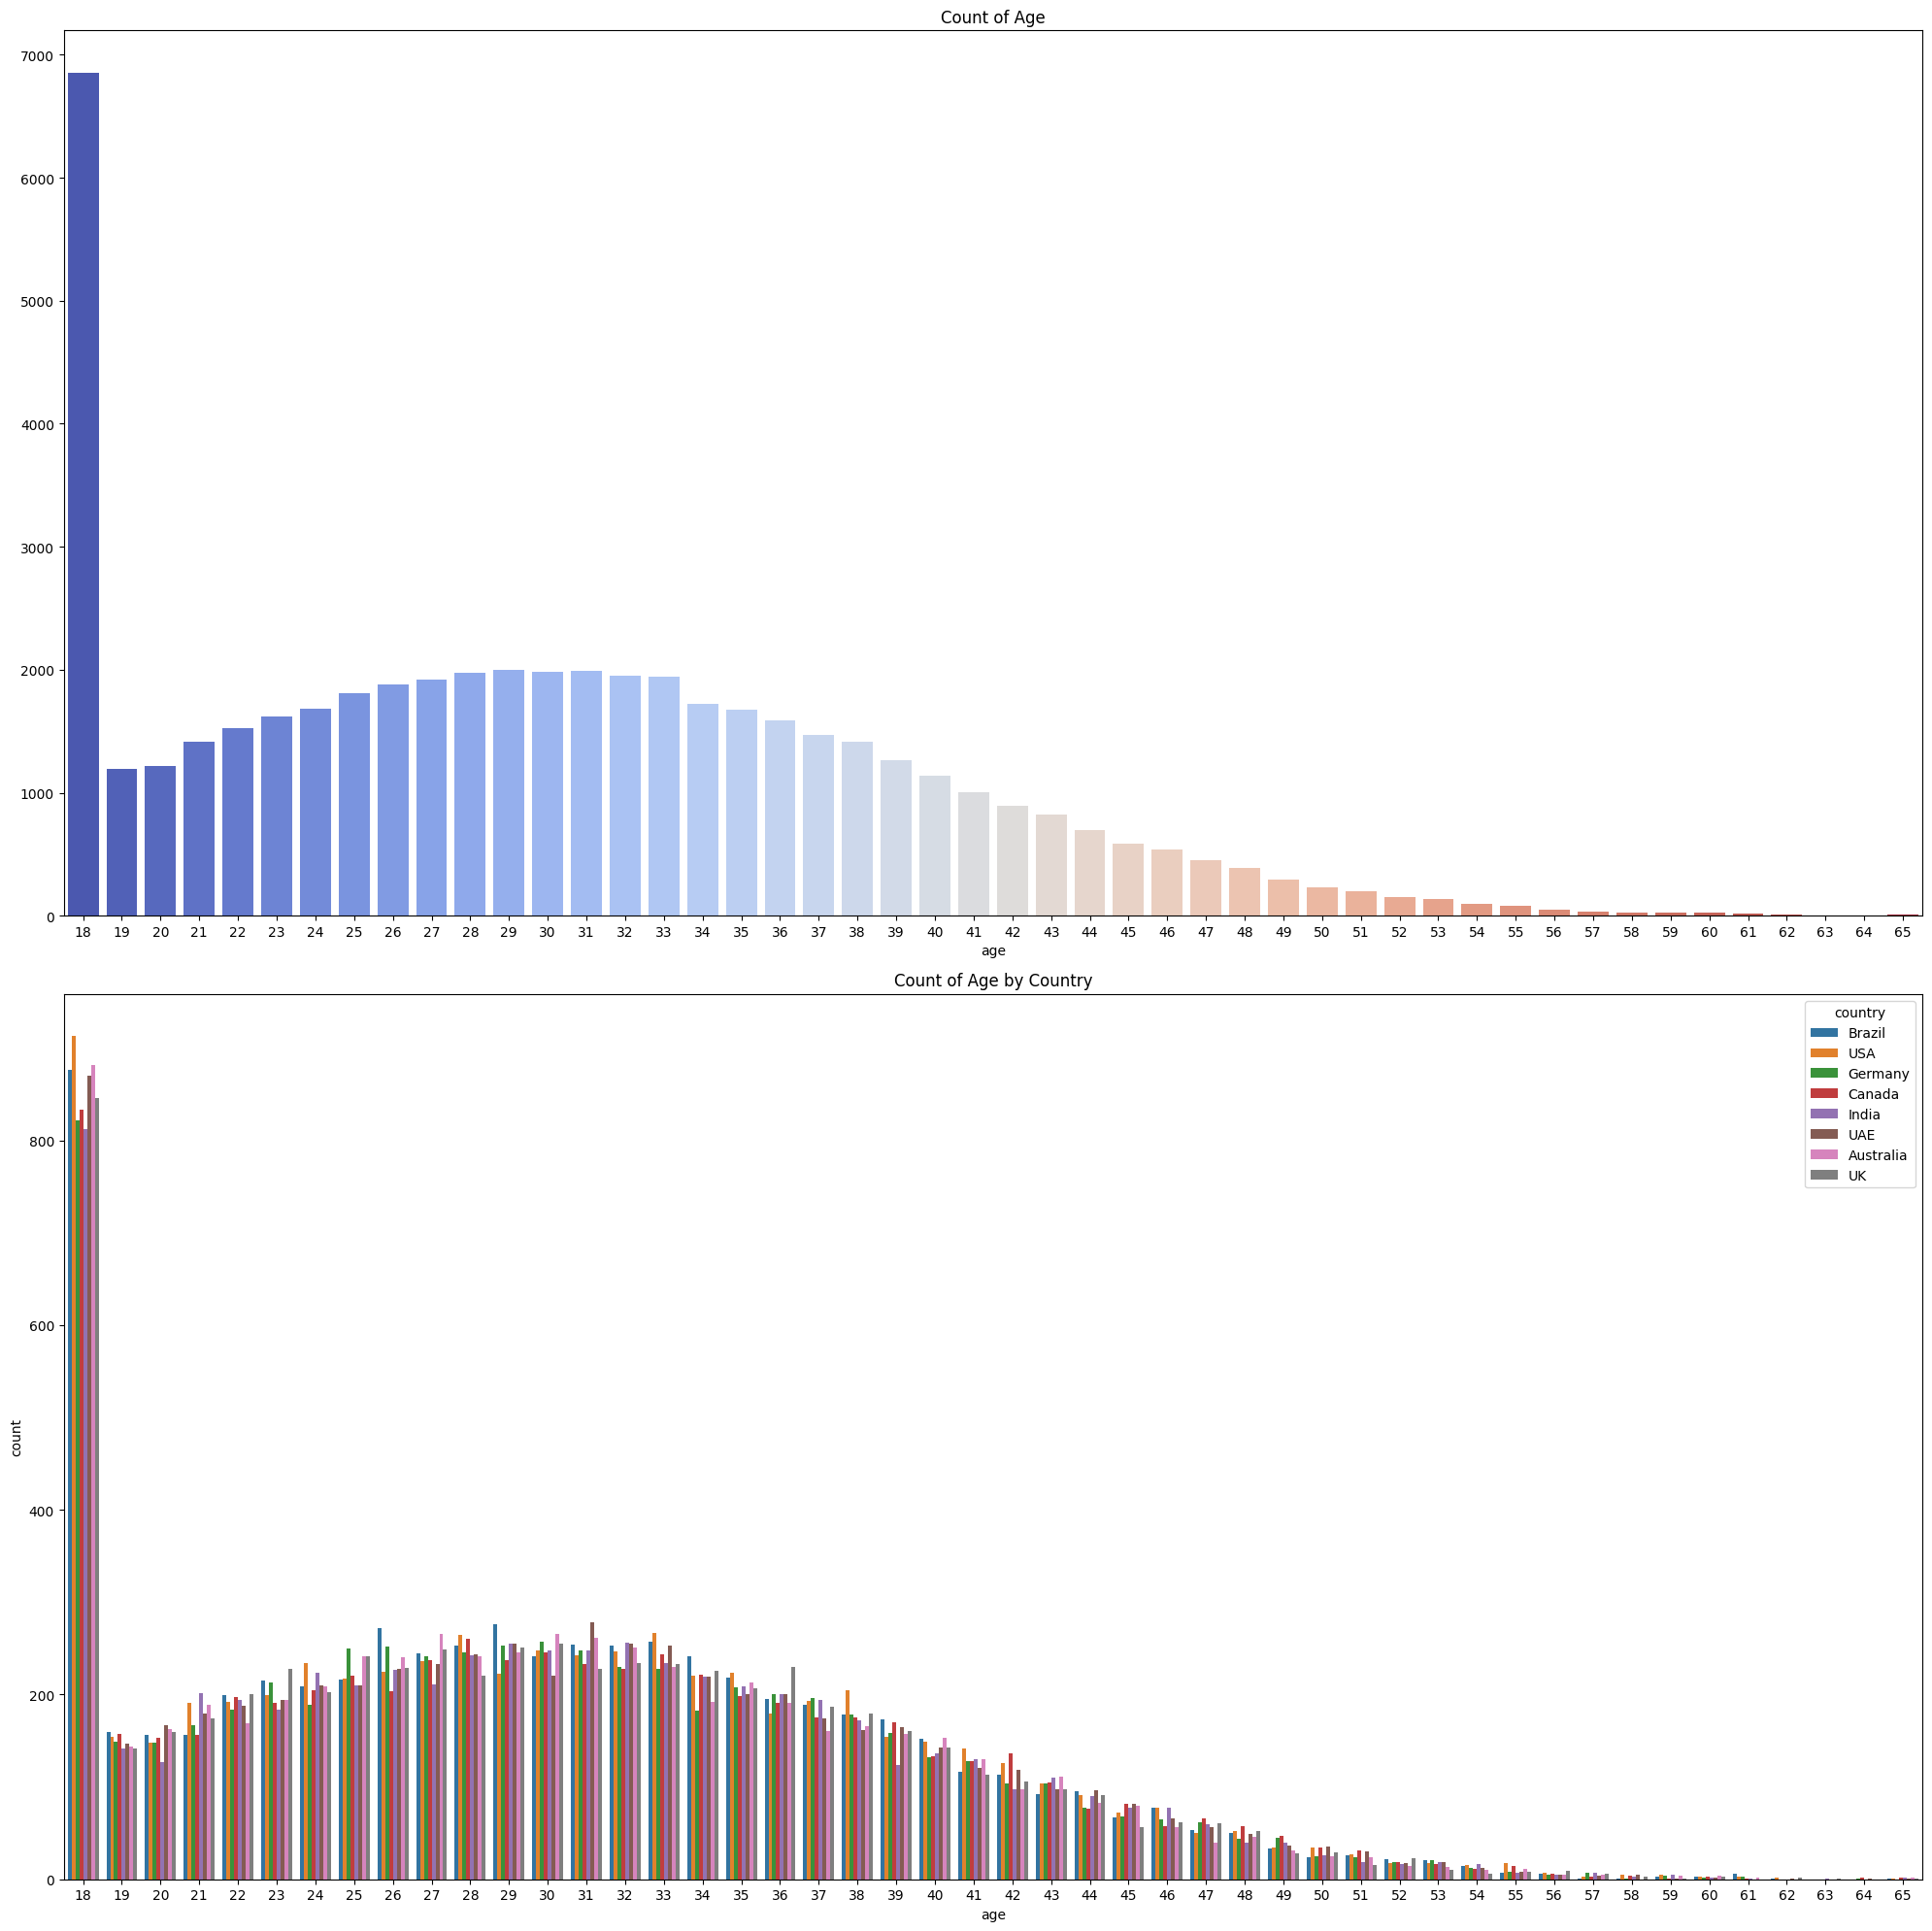

In [468]:
fig, ax = plt.subplots(2, 1, figsize=(20, 20))

sns.barplot(x=data['age'].value_counts().index, 
            y=data['age'].value_counts().values,
            palette='coolwarm', 
            alpha=1, 
            ax=ax[0], 
            hue=data['age'].value_counts().index,
            legend=False)

ax[0].set_title(f'Count of Age');

sns.countplot(x='age', 
              hue='country', 
              data=data, 
              ax=ax[1])
ax[1].set_title(f'Count of Age by Country');

plt.tight_layout()
plt.show()

**Верхний график: "Count of Age"**

* Этот график показывает распределение возраста среди всей выборки. 
* Из графика видно, что возраст 18 лет является наиболее часто встречаемым, за ним следуют 25-35 лет c небольшим пиком, что может свидетельствовать о преобладании молодежной аудитории в данных. 
* После этого наблюдается постепенное снижение частоты с увеличением возраста. Это может быть связано с тем, что среди более старших возрастных групп количество пользователей или респондентов меньше.

**Нижний график: "Count of Age by Country"**

* Этот график представляет распределение возраста по странам, причем для каждой возрастной категории отображены данные по 8 странам (Бразилия, США, Германия, Канада, Индия, ОАЭ, Австралия и Великобритания). 
* Видно, что в распределение возрастных групп по странам нет разницы.

`Brand`/`Model` - Марка мобильного телефона/Модель мобильного телефона

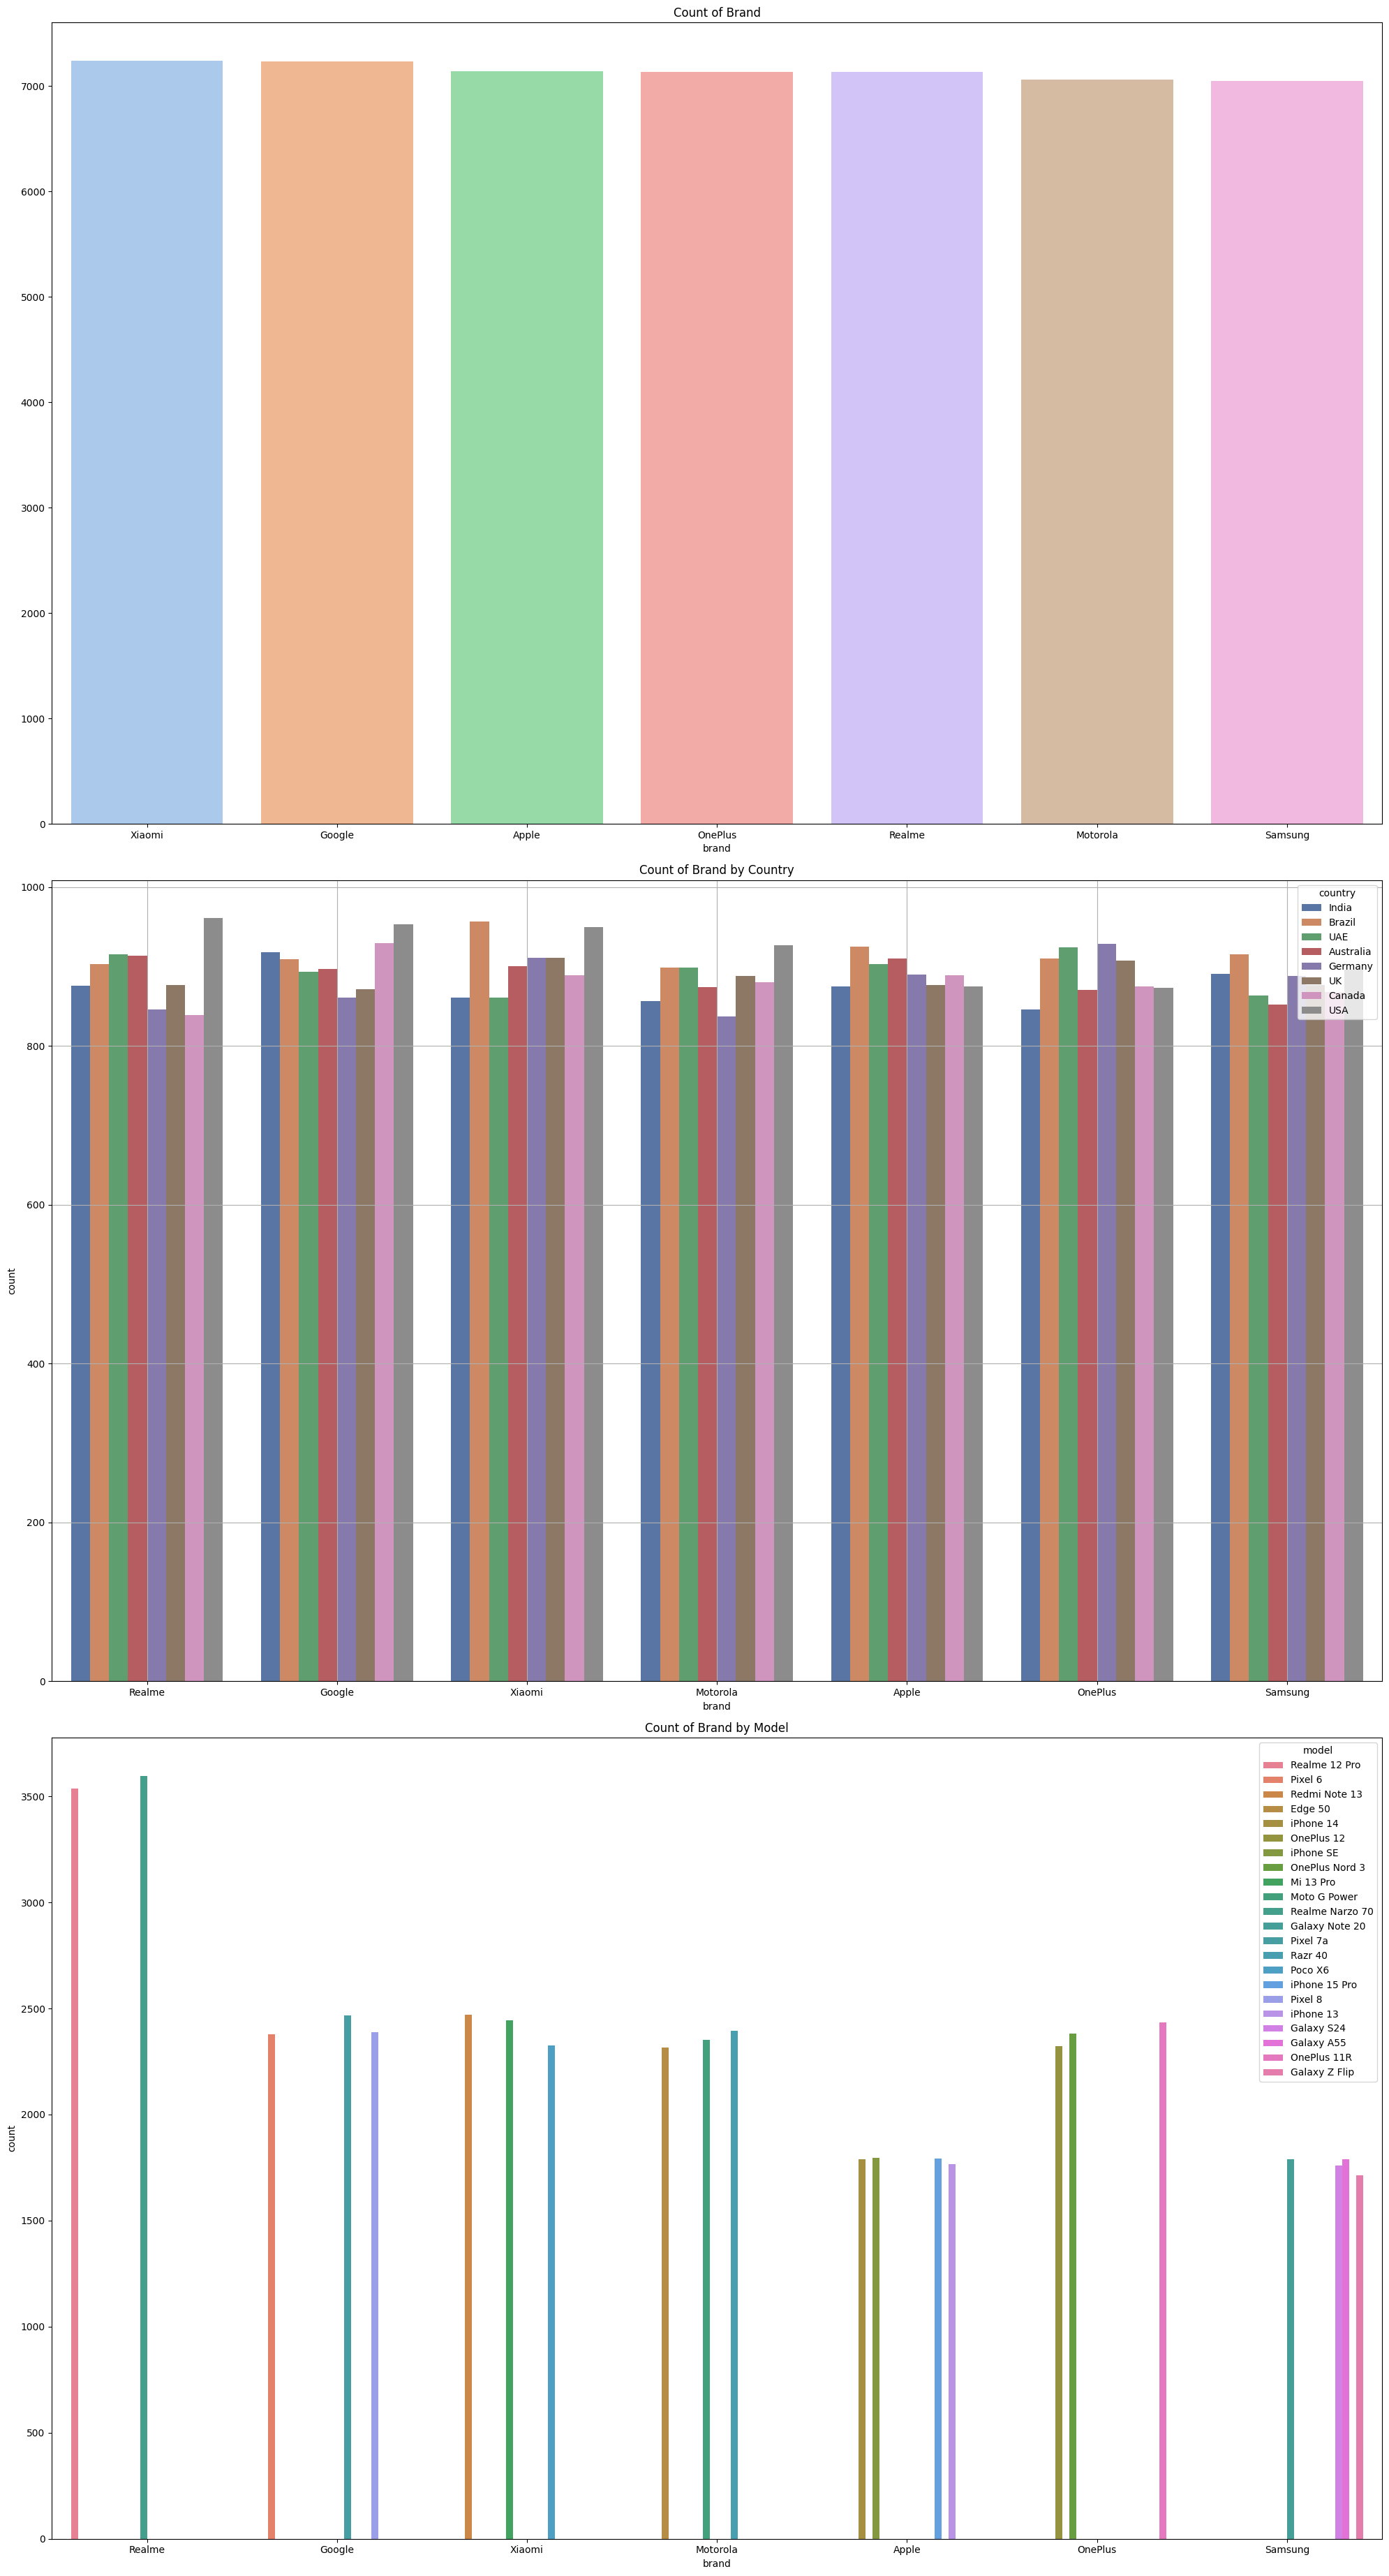

In [469]:
fig, ax = plt.subplots(3, 1, figsize=(20, 37))

sns.barplot(x=data['brand'].value_counts().index, 
            y=data['brand'].value_counts().values,
            alpha=1, 
            palette='pastel',
            hue=data['brand'].value_counts().index,
            ax=ax[0]);
ax[0].set_title(f'Count of Brand');

sns.countplot(x='brand', 
              hue='country', 
              data=data, 
              palette='deep', 
              ax=ax[1])
ax[1].set_title(f'Count of Brand by Country');
ax[1].grid(True)

sns.countplot(data=data, x='brand', hue='model', alpha=1, ax=ax[2]);
ax[2].set_title(f'Count of Brand by Model');

plt.tight_layout()
plt.show()

**График: "Count of Brand"**

* Этот график показывает распределение количества устройств по брендам смартфонов.
* Из графика видно, что все бренды — Xiaomi, Google, Apple, OnePlus, Realme, Motorola и Samsung — представлены практически одинаковым количеством данных, находящимся в диапазоне примерно 7100–7300 записей.
* Такое равномерное распределение говорит о том, что датасет, вероятнее всего, сбалансирован искусственно или сформирован так, чтобы каждая категория бренда была представлена одинаково.
* Существенных различий между брендами не наблюдается: ни один бренд не доминирует и не отстаёт, что исключает смещение в сторону какой-либо конкретной марки.

**График: "Count of Brand by Country"**

* Этот график показывает распределение количества устройств по брендам с разделением по странам. Для каждого бренда отображены данные по 8 странам: Индия, Бразилия, ОАЭ, Австралия, Германия, Великобритания, Канада и США.
* Как видно из графика, распределение по странам почти одинаковое для каждого бренда: высота столбцов в пределах одной группы различается минимально. Это говорит о том, что каждая страна представлена в данных равномерно для каждого бренда.
* Существенных различий в популярности брендов между странами не наблюдается: ни один бренд не доминирует в конкретной стране, и наоборот — ни одна страна не выделяется сильнее других внутри каждого бренда.

**График: "Count of Brand by Model"**

* Этот график показывает распределение количества устройств по моделям внутри каждого бренда. Для каждого бренда представлены несколько конкретных моделей, и для каждой модели отображено количество встреч в данных.
* Из графика видно, что каждый бренд имеет несколько моделей, но число устройств внутри одной модели примерно одинаковое. Например, такие модели как Realme 12 Pro, Pixel 6, Redmi Note 13, iPhone 14, OnePlus Nord 3, Galaxy S24 и другие показывают сопоставимые значения частоты (в диапазоне примерно 1700–3600).
* Если сравнивать бренды между собой, заметно, что число моделей у разных производителей различается, но общие частоты по моделям остаются близкими, что поддерживает одинаковый вес брендов в данных.

`Price_usd` - Цена товара в долларах

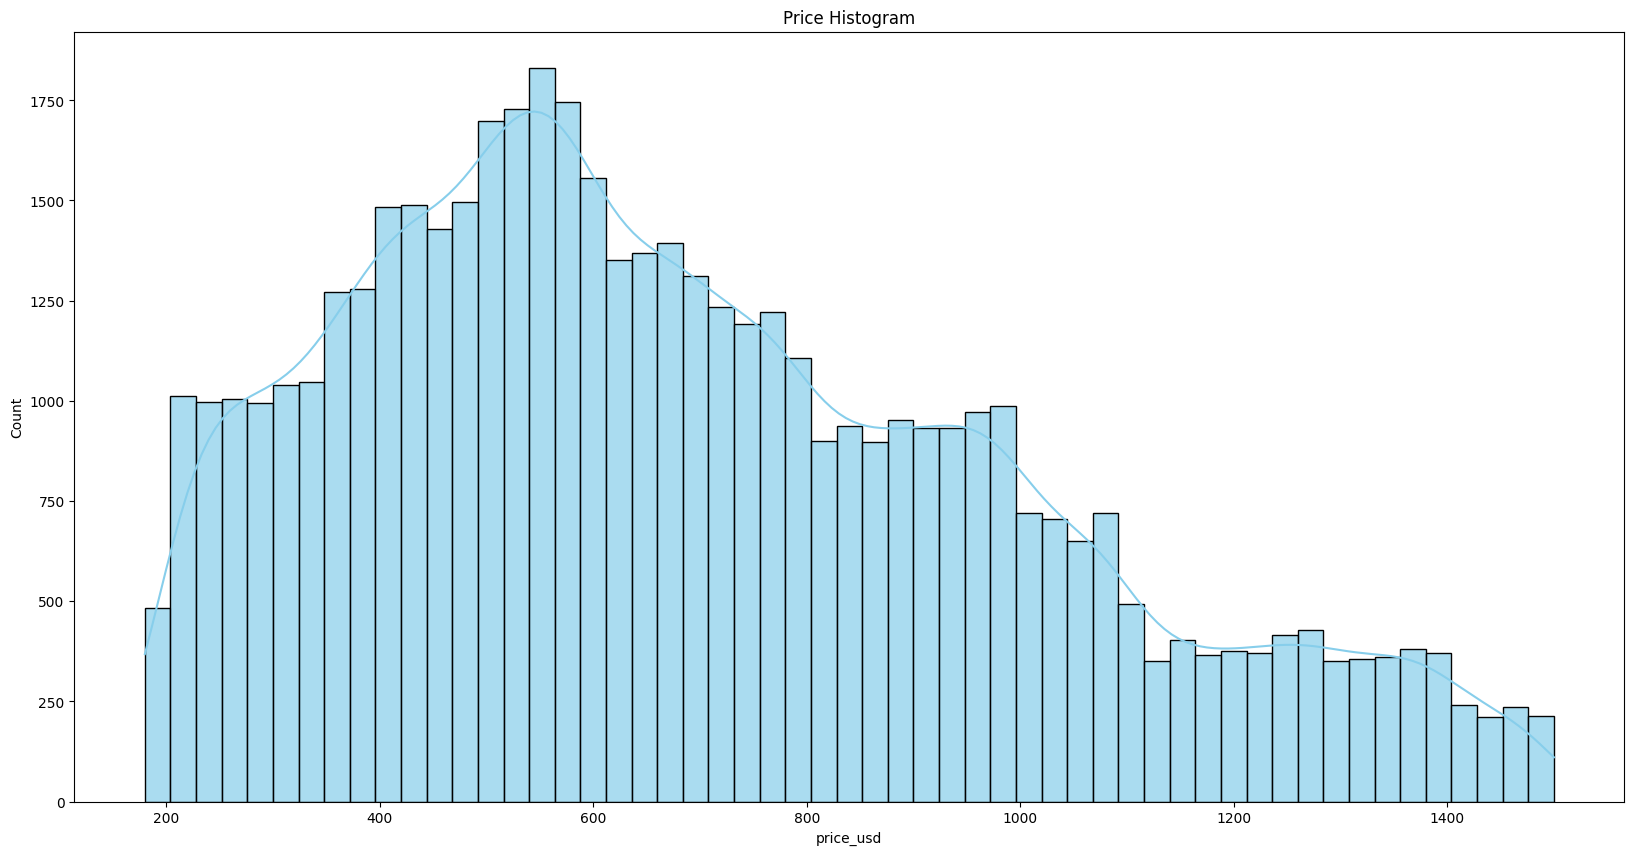

In [470]:
plt.figure(figsize=(20, 10))

sns.histplot(data['price_usd'], bins='auto', color='skyblue', alpha=0.7, kde=True)

plt.title('Price Histogram')
plt.show()


**График: "Price Histogram"**

* Этот график показывает распределение цен на устройства в долларах США (price_usd).
* Видно, что цены имеют асимметричное распределение, смещённое в сторону более низких значений. Наибольшее количество устройств находится в диапазоне от 400 до 700 USD, где наблюдается выраженный пик частоты.
* Начиная примерно с 800 USD, количество устройств постепенно снижается, что отражает привычную картину рынка: высокобюджетные устройства встречаются реже.
* В левой части графика заметен небольшой всплеск в сегменте до 300 USD, что может соответствовать бюджетным моделям брендов вроде Realme, Xiaomi или Motorola.
* Линия KDE (плавная кривая плотности) подчёркивает общую форму распределения: однопиковое, правосторонне скошенное, что является типичным для ценовых данных в электронике.

`Currency` - Валюта, в которой указана цена

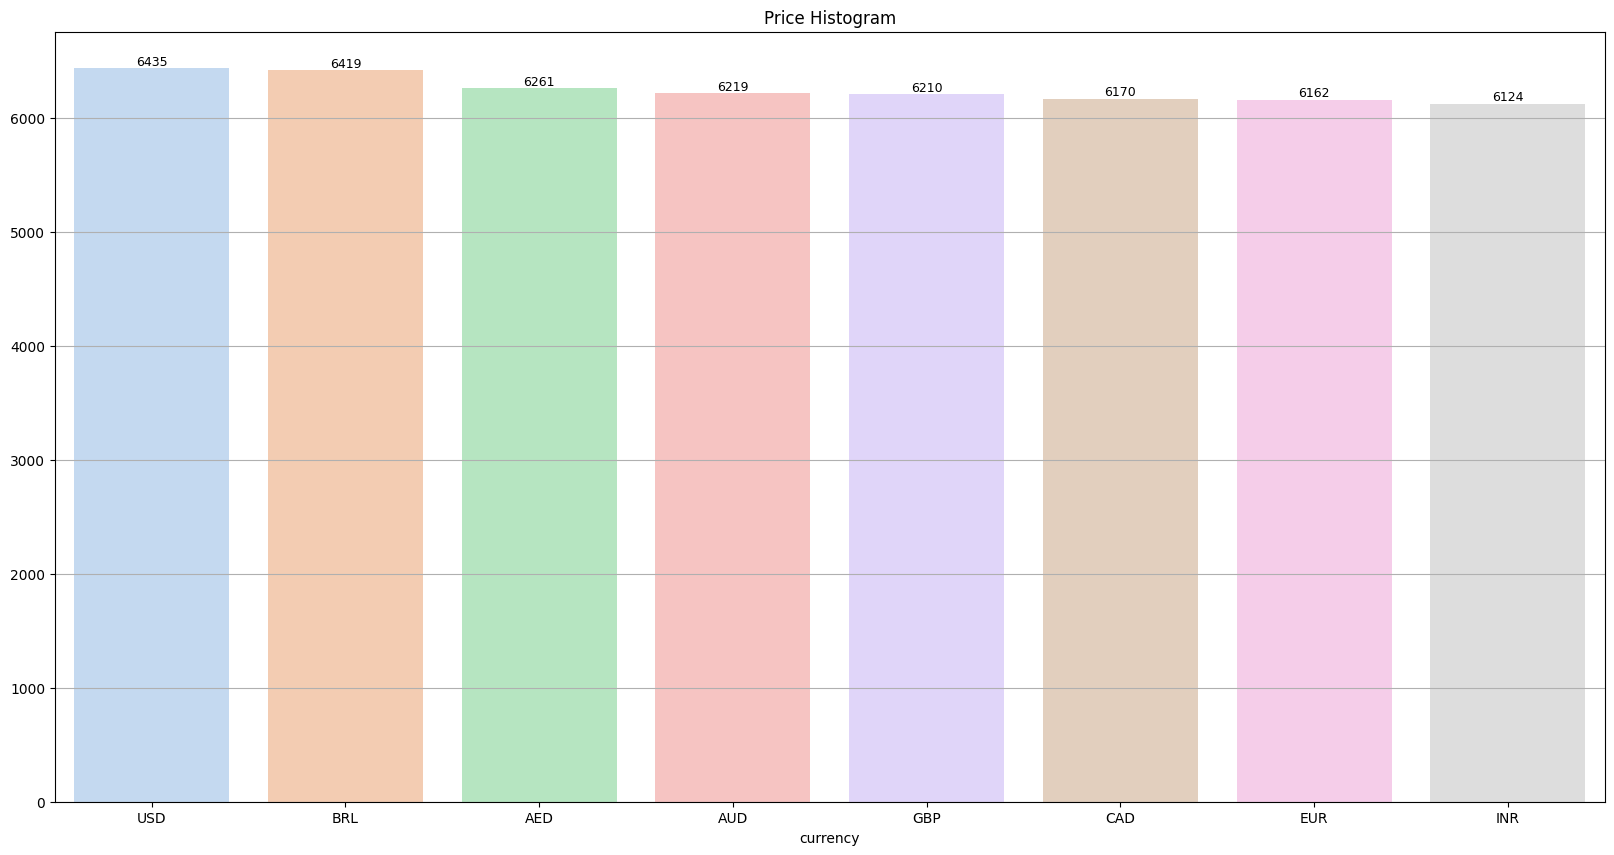

In [471]:
plt.figure(figsize=(20, 10))

ax=sns.barplot(x=data['currency'].value_counts().index, 
                y=data['currency'].value_counts().values, 
                alpha=0.7, 
                orient='x', 
                palette='pastel',
                hue=data['currency'].value_counts().index)

for cont in ax.containers:
    ax.bar_label(cont, fontsize=9);

plt.title('Price Histogram')
plt.grid(axis='y')
#plt.tight_layout()
plt.show()


**График: "Price Histogram" (Currency Distribution)**

* Этот график показывает распределение количества записей по валютам, используемым в данных. На оси X представлены валюты (USD, BRL, AED, AUD, GBP, CAD, EUR, INR), а по оси Y — количество купленных устройств, указанных в каждой из этих валют.
* Из графика видно, что различия между валютами минимальны: количество записей находится в диапазоне примерно 6120–6435, без явных выбросов или резких скачков.
* Это говорит о том, что датасет сформирован равномерно по каждой валюте, что исключает смещение в сторону какой-либо конкретной страны или региона.

`Rating` - Оценка отзыва

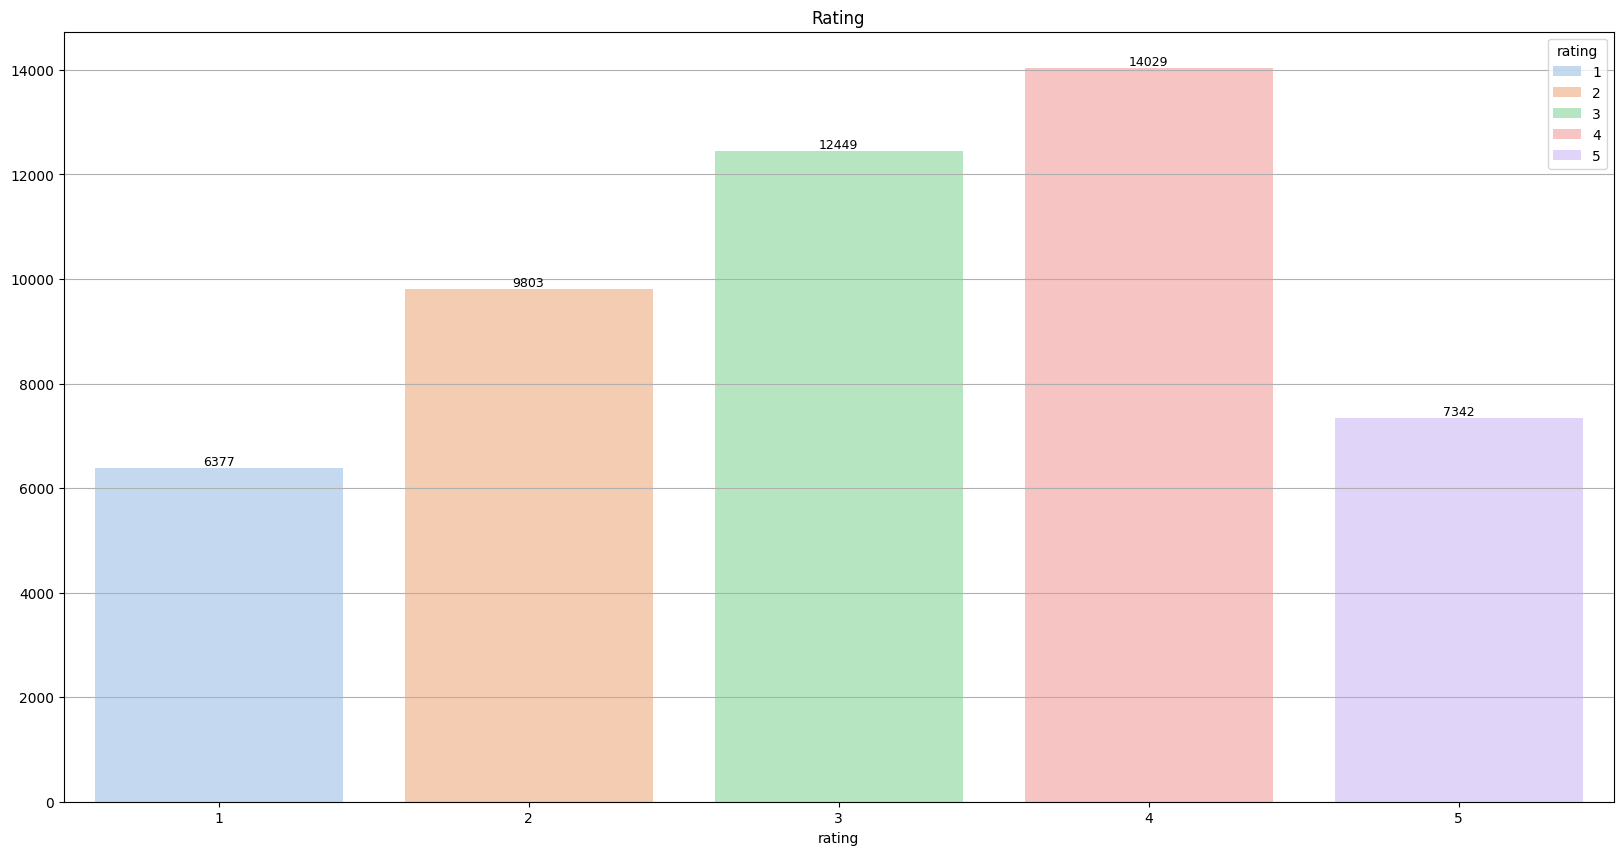

In [472]:
plt.figure(figsize=(20, 10))

ax=sns.barplot(x=data['rating'].value_counts().index, 
                y=data['rating'].value_counts().values, 
                alpha=0.7, 
                orient='x', 
                palette='pastel',
                hue=data['rating'].value_counts().index)

for cont in ax.containers:
    ax.bar_label(cont, fontsize=9);

plt.title('Rating')
plt.grid(axis='y')
plt.show()

**График: "Rating"**

* Этот график показывает распределение пользовательских оценок от 1 до 5. Каждая колонка отображает, сколько раз встречается соответствующий рейтинг в датасете.
* Из графика видно, что наиболее частыми являются оценки 3 и 4, причём рейтинг 4 является самым популярным — он встречается более 14 000 раз. Это может указывать на то, что пользователи чаще склонны оставлять позитивные или умеренно позитивные оценки.
* Рейтинги 1 и 5 встречаются заметно реже. Низкие оценки (1) представлены минимально — около 6 300 раз, что говорит либо о низком уровне негатива, либо о том, что пользователи оставляют отзывы чаще, когда довольны устройством.
* Рейтинг 5 встречается чаще единиц, но значительно реже, чем 3 и 4. Это может отражать типичную ситуацию: максимальные оценки пользователи оставляют реже, предпочитая более умеренные баллы.
* В целом распределение напоминает лёгкую “горку”, где пик приходится на средние значения (3–4), что характерно для больших пользовательских выборок, где экстремальные оценки встречаются реже.

`Sentiment` - Эмоциональная окраска отзыва

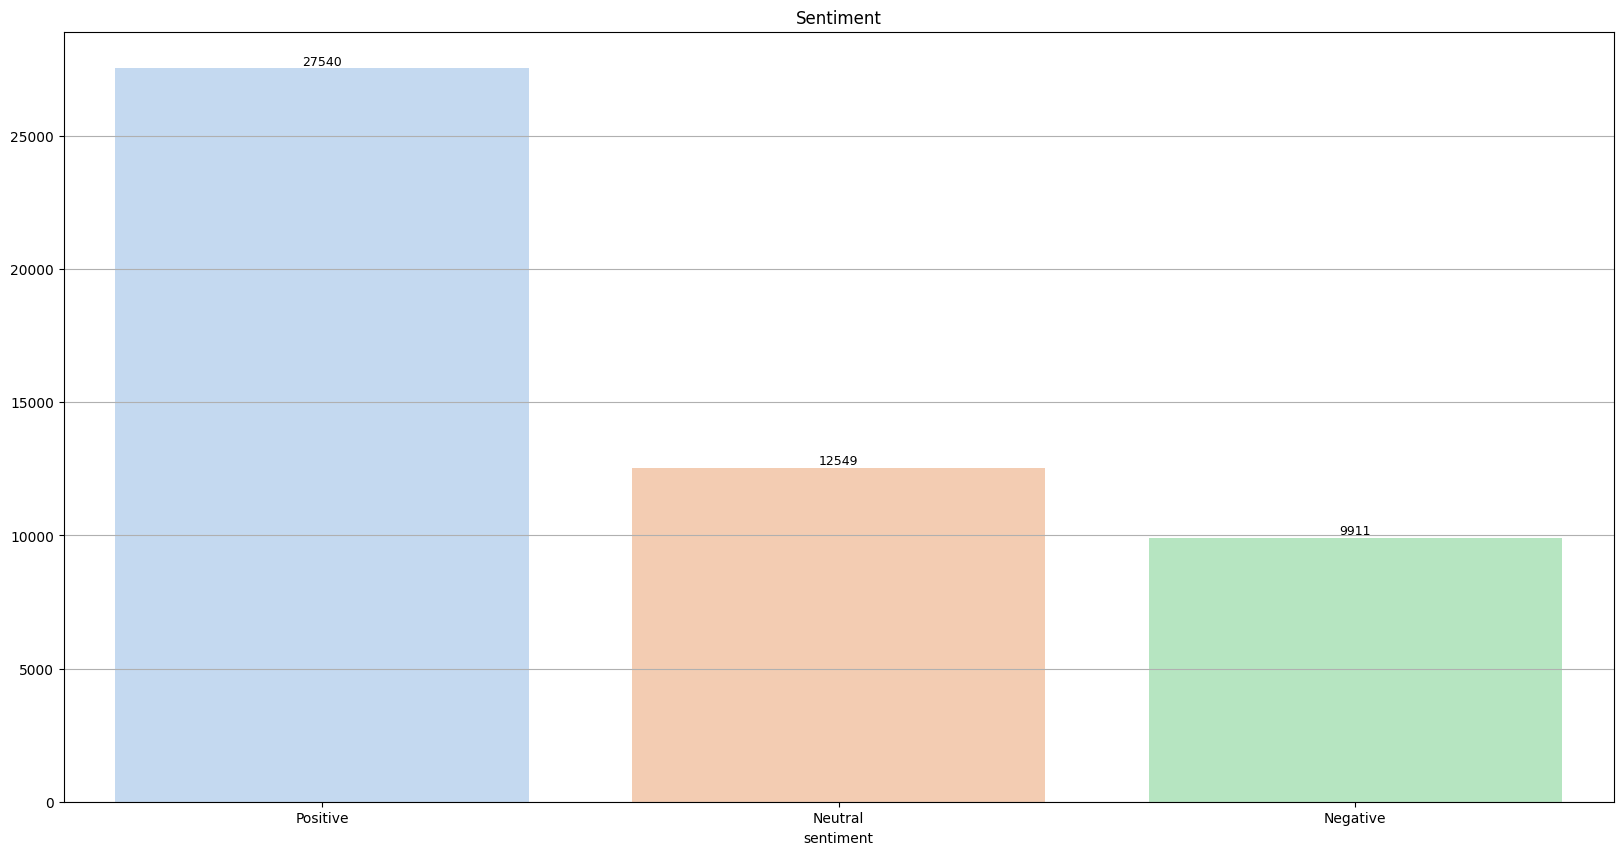

In [473]:
plt.figure(figsize=(20, 10))

ax=sns.barplot(x=data['sentiment'].value_counts().index, 
                y=data['sentiment'].value_counts().values, 
                alpha=0.7, 
                orient='x', 
                palette='pastel',
                hue=data['sentiment'].value_counts().index)

for cont in ax.containers:
    ax.bar_label(cont, fontsize=9);

plt.title('Sentiment')
plt.grid(axis='y')
plt.show()

**График: "Sentiment"**

* Этот график показывает распределение тональности пользовательских отзывов, классифицированных на три категории: Positive, Neutral и Negative.
* Наиболее крупную долю занимают позитивные отзывы — их насчитывается около 27 540, что составляет более половины от всех записей. Это говорит о том, что пользователи в целом склонны положительно оценивать свои устройства и делиться благоприятным впечатлением.
* Нейтральные отзывы встречаются значительно реже — примерно 12 549 записей. Такая доля указывает на то, что часть пользователей остаётся спокойной и объективной в своих комментариях, однако нейтральная тональность заметно уступает позитивной.
* Категория Negative является наименее представленной — около 9 911 отзывов. Это может говорить о том, что серьёзное недовольство встречается реже, или о том, что пользователи проявляют меньшую активность, когда опыт был негативным.
* В целом распределение отражает неравномерность тональности: доминируют позитивные эмоции, затем идут нейтральные и негативные. Такое соотношение характерно для многих пользовательских платформ, где довольные пользователи чаще проявляют активность.

`Review_date` - Дата публикации отзыва.

In [474]:
data['review_date'].head(5)

0    2023-11-06
1    2023-03-30
2    2022-12-07
3    2025-03-11
4    2023-09-29
Name: review_date, dtype: object

In [475]:
data['review_date'] = pd.to_datetime(data['review_date'], format='%Y-%m-%d')

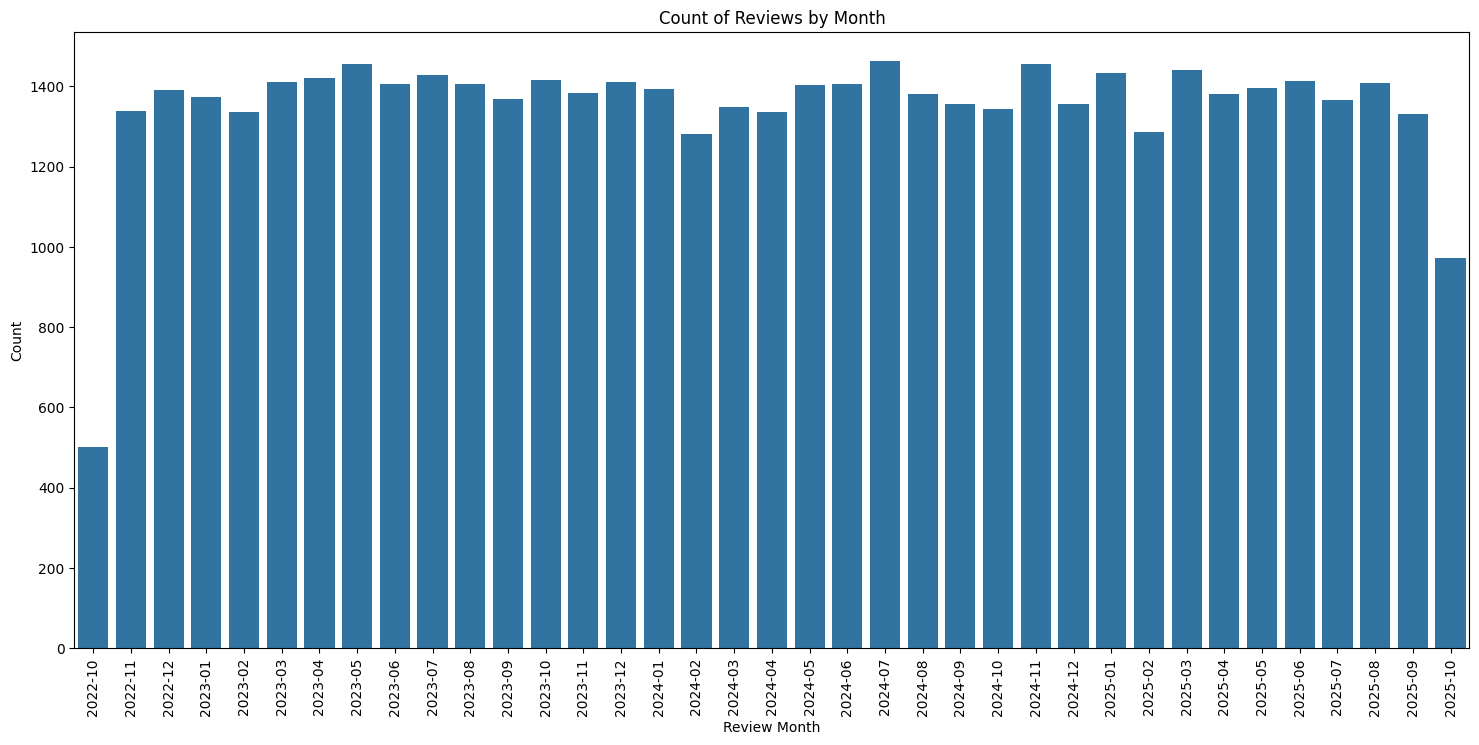

In [476]:
data['review_month'] = data['review_date'].dt.to_period('M')

plt.figure(figsize=(18, 8))
sns.barplot(x='review_month', y='count', data=data.groupby('review_month').size().reset_index(name='count'))

plt.xticks(rotation=90)

plt.title('Count of Reviews by Month')
plt.xlabel('Review Month')
plt.ylabel('Count')


plt.show()



In [477]:
data = data.drop(columns=['review_month'])

**График: "Count of Reviews by Month"**

* Этот график показывает количество отзывов, оставленных по месяцам. Каждая колонка представляет количество отзывов за соответствующий месяц.
* Из графика видно, что большинство месяцев имеют примерно одинаковое количество отзывов в пределах 700–1400. Это может говорить о стабильности потока данных, что предполагает равномерное распределение активности пользователей на протяжении времени.
* Однако, октябрь 2022 года выделяется на графике с резким падением количества отзывов — всего около 400. Это может быть связано с временными изменениями в доступности устройства, сезонами продаж или другими внешними факторами, влияющими на активность пользователей в этом месяце или месяц неполный.
* Остальные месяцы, начиная с ноября 2022 и до октября 2025 года, почти равномерно распределены, что подтверждает стабильную активность пользователей.

`Verified_purchase` - Был ли товар реально приобретен покупателем.

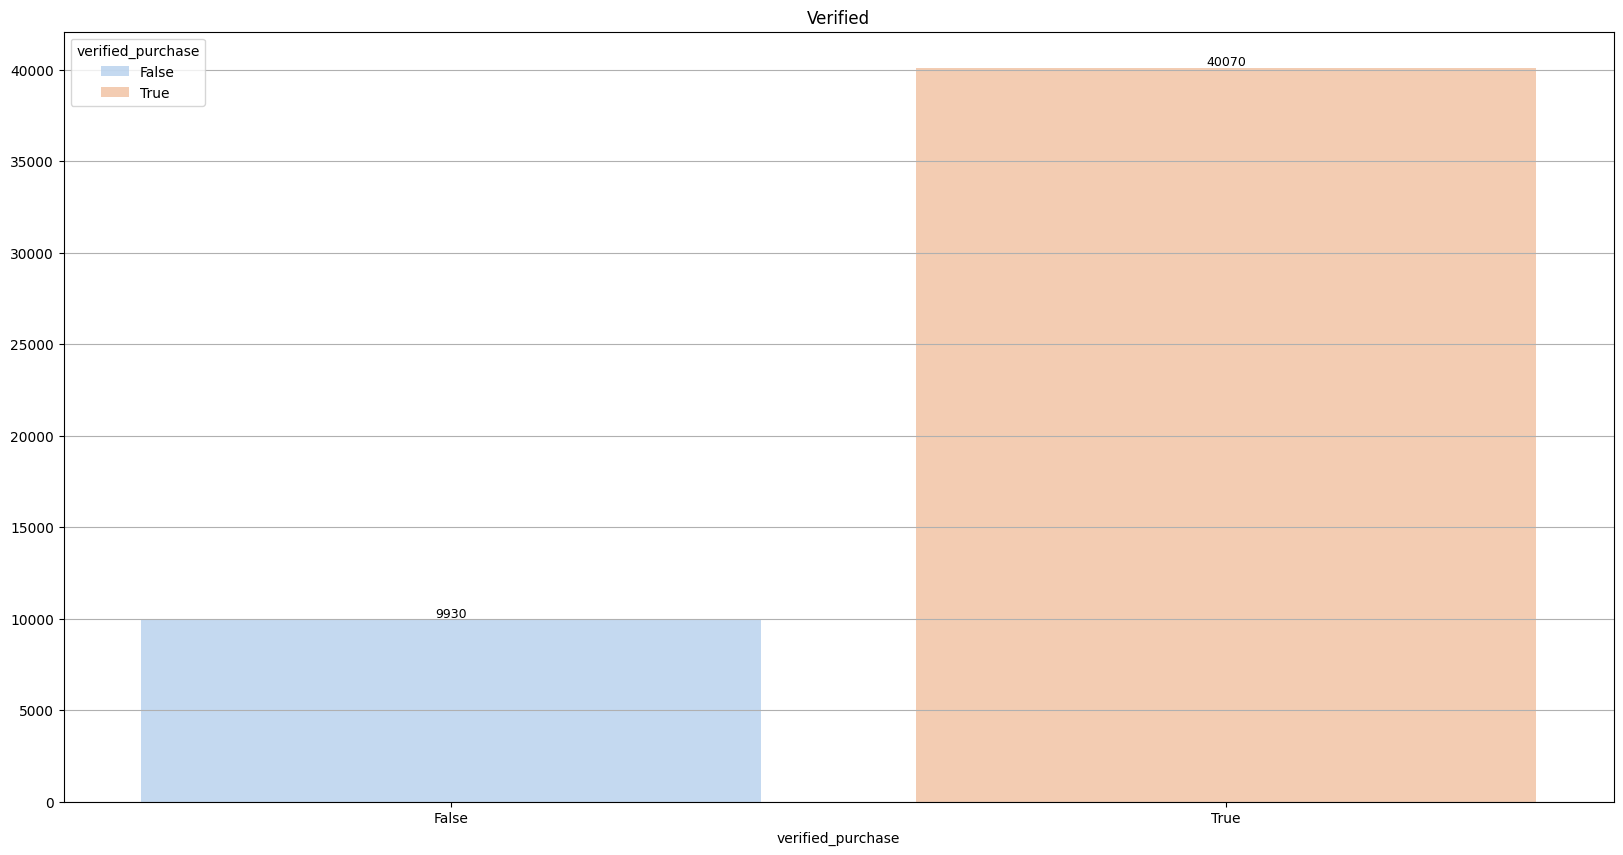

In [478]:
plt.figure(figsize=(20, 10))

ax=sns.barplot(x=data['verified_purchase'].value_counts().index, 
                y=data['verified_purchase'].value_counts().values, 
                alpha=0.7, 
                orient='x', 
                palette='pastel',
                hue=data['verified_purchase'].value_counts().index)

for cont in ax.containers:
    ax.bar_label(cont, fontsize=9);

plt.title('Verified')
plt.grid(axis='y')
plt.show()

**График: "Sentiment by Verified Purchase"**

* Этот график показывает распределение тональности отзывов по категории подтверждённых покупок (verified_purchase). Данные делятся на две группы: True (подтверждённые покупки) и False (неподтверждённые покупки).
* Из графика видно, что большинство отзывов приходится на подтверждённые покупки (True), их количество составляет около 40 070. Это может указывать на то, что пользователи, которые покупают товар, оставляют отзывы чаще или что они более склонны к оставлению отзывов.
* В то же время, неподтверждённые покупки (False) составляют всего около 9 930 отзывов, что значительно меньше, чем в категории True. Это может означать, что пользователи, не совершившие покупку, оставляют отзывы реже, или же эти отзывы могут быть менее надежными.
* Сильный дисбаланс в данных между этими двумя категориями (подтверждённые и неподтверждённые) указывает на важность подтверждения покупки для оставления отзыва, и это может влиять на интерпретацию отзывов и анализ sentiment.

`Evaluation` (battery_life_rating, camera_rating, performance_rating,design_rating, display_rating) - Оценка качеств телефона

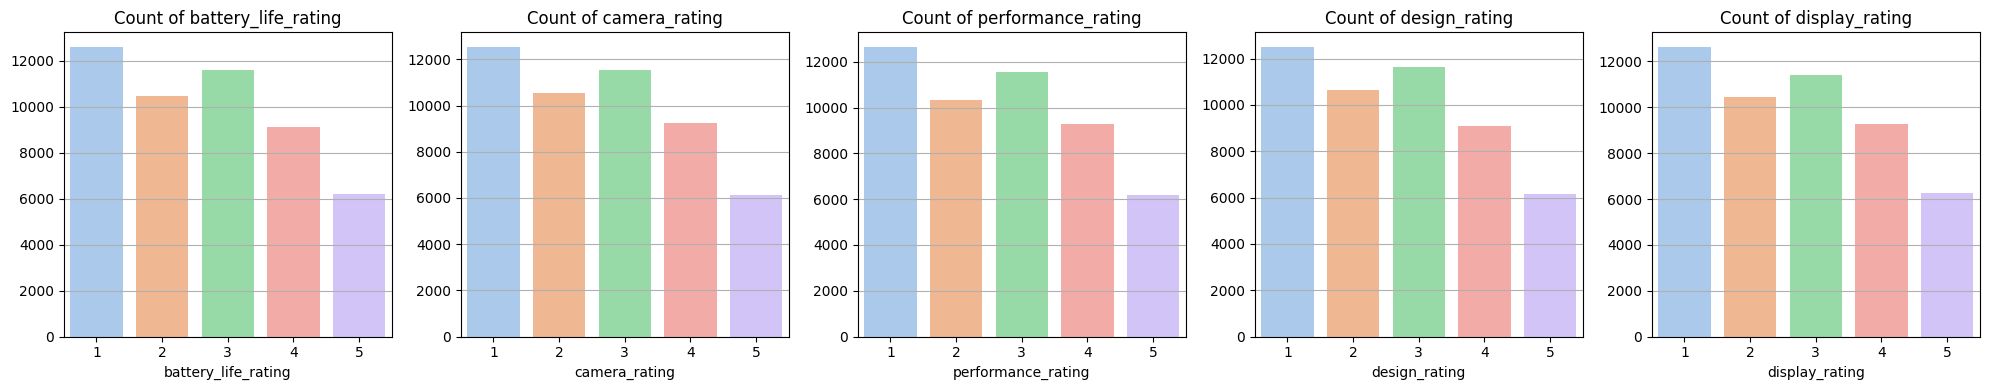

In [479]:
fig, ax = plt.subplots(1, 5, figsize=(20, 4))

ratings = ['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']

for i, rating in enumerate(ratings):
    sns.barplot(x=data[rating].value_counts().index, 
                y=data[rating].value_counts().values,
                alpha=1, 
                palette='pastel',
                ax=ax[i],
                hue=data[rating].value_counts().index,
                legend=False);
    ax[i].set_title(f'Count of {rating}');
    ax[i].grid(axis='y')


plt.tight_layout()
plt.show()

**График: "Ratings by Category"**

* Этот график показывает распределение оценок для разных характеристик продукта: battery life, camera, performance, design, display. Каждая колонка представляет количество отзывов для каждой оценки (от 1 до 5) по каждой из категорий.
* Из графиков видно, что для большинства категорий оценка 1 является наиболее часто встречаемой. Это говорит о том, что пользователи чаще ставят негативные оценки для этих характеристик.
* Оценки 4 и 5 встречаются реже, но они все равно составляют значительную долю в данных, что говорит о том, что пользователи оставляют положительные отзывы.

`Source` - Источник отзыва

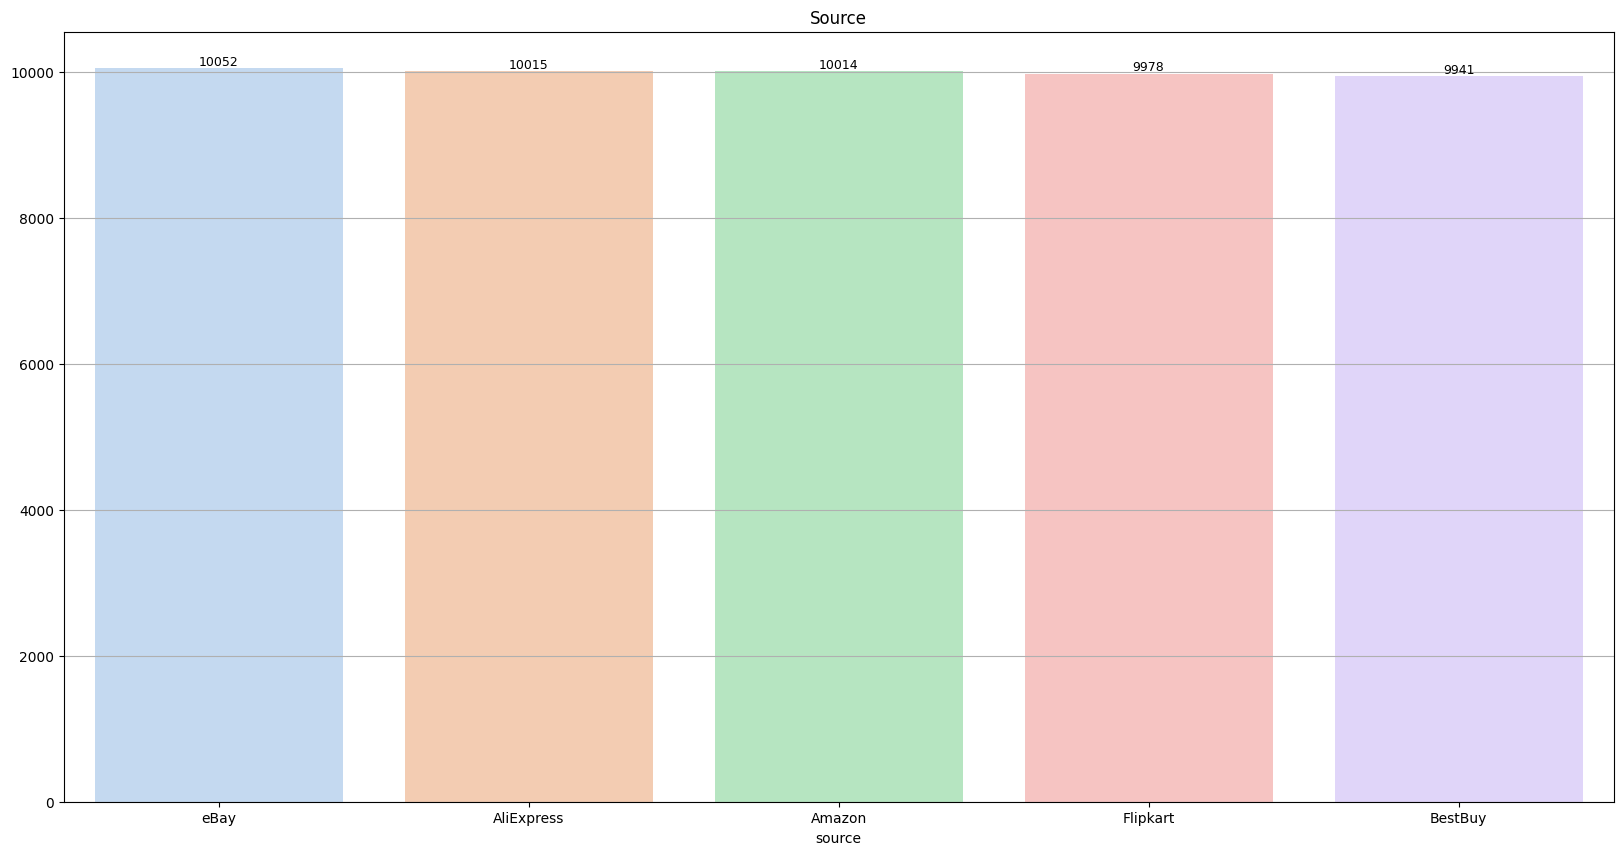

In [480]:
plt.figure(figsize=(20, 10))

ax=sns.barplot(x=data['source'].value_counts().index, 
                y=data['source'].value_counts().values, 
                alpha=0.7, 
                orient='x', 
                palette='pastel',
                hue=data['source'].value_counts().index)

for cont in ax.containers:
    ax.bar_label(cont, fontsize=9);

plt.title('Source')
plt.grid(axis='y')
plt.show()

**График: "Sentiment by Source"**

* Этот график показывает распределение отзывов по источникам (платформам): eBay, AliExpress, Amazon, Flipkart, и BestBuy.
* Все платформы показывают примерно одинаковое количество отзывов.

#### 2.4. Приведение к нормальным типом данных

`price_local`

In [481]:
data['price_local'] = data['price_local'].apply(lambda x: re.sub(r'[^\d.]', '', str(x)))
data['price_local'] = data['price_local'].apply(lambda x: re.sub(r'^\.', '', str(x)))

In [482]:
data['price_local'] = data['price_local'].astype('float')

`sentiment`

In [483]:
data['sentiment'] = data['sentiment'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})

`verified_purchase`

In [484]:
data['verified_purchase'] = data['verified_purchase'].map({False: 0, True: 1})

#### 2.5. Проверка на мультиколлениарность

In [485]:
data_corr = data.copy()

In [491]:
data_corr = data_corr.drop(columns=['review_date'])

In [492]:
categorical_columns = data_corr.select_dtypes(include=['object']).columns.to_list()
numeric_columns = data_corr.select_dtypes(exclude=['object']).columns.to_list()

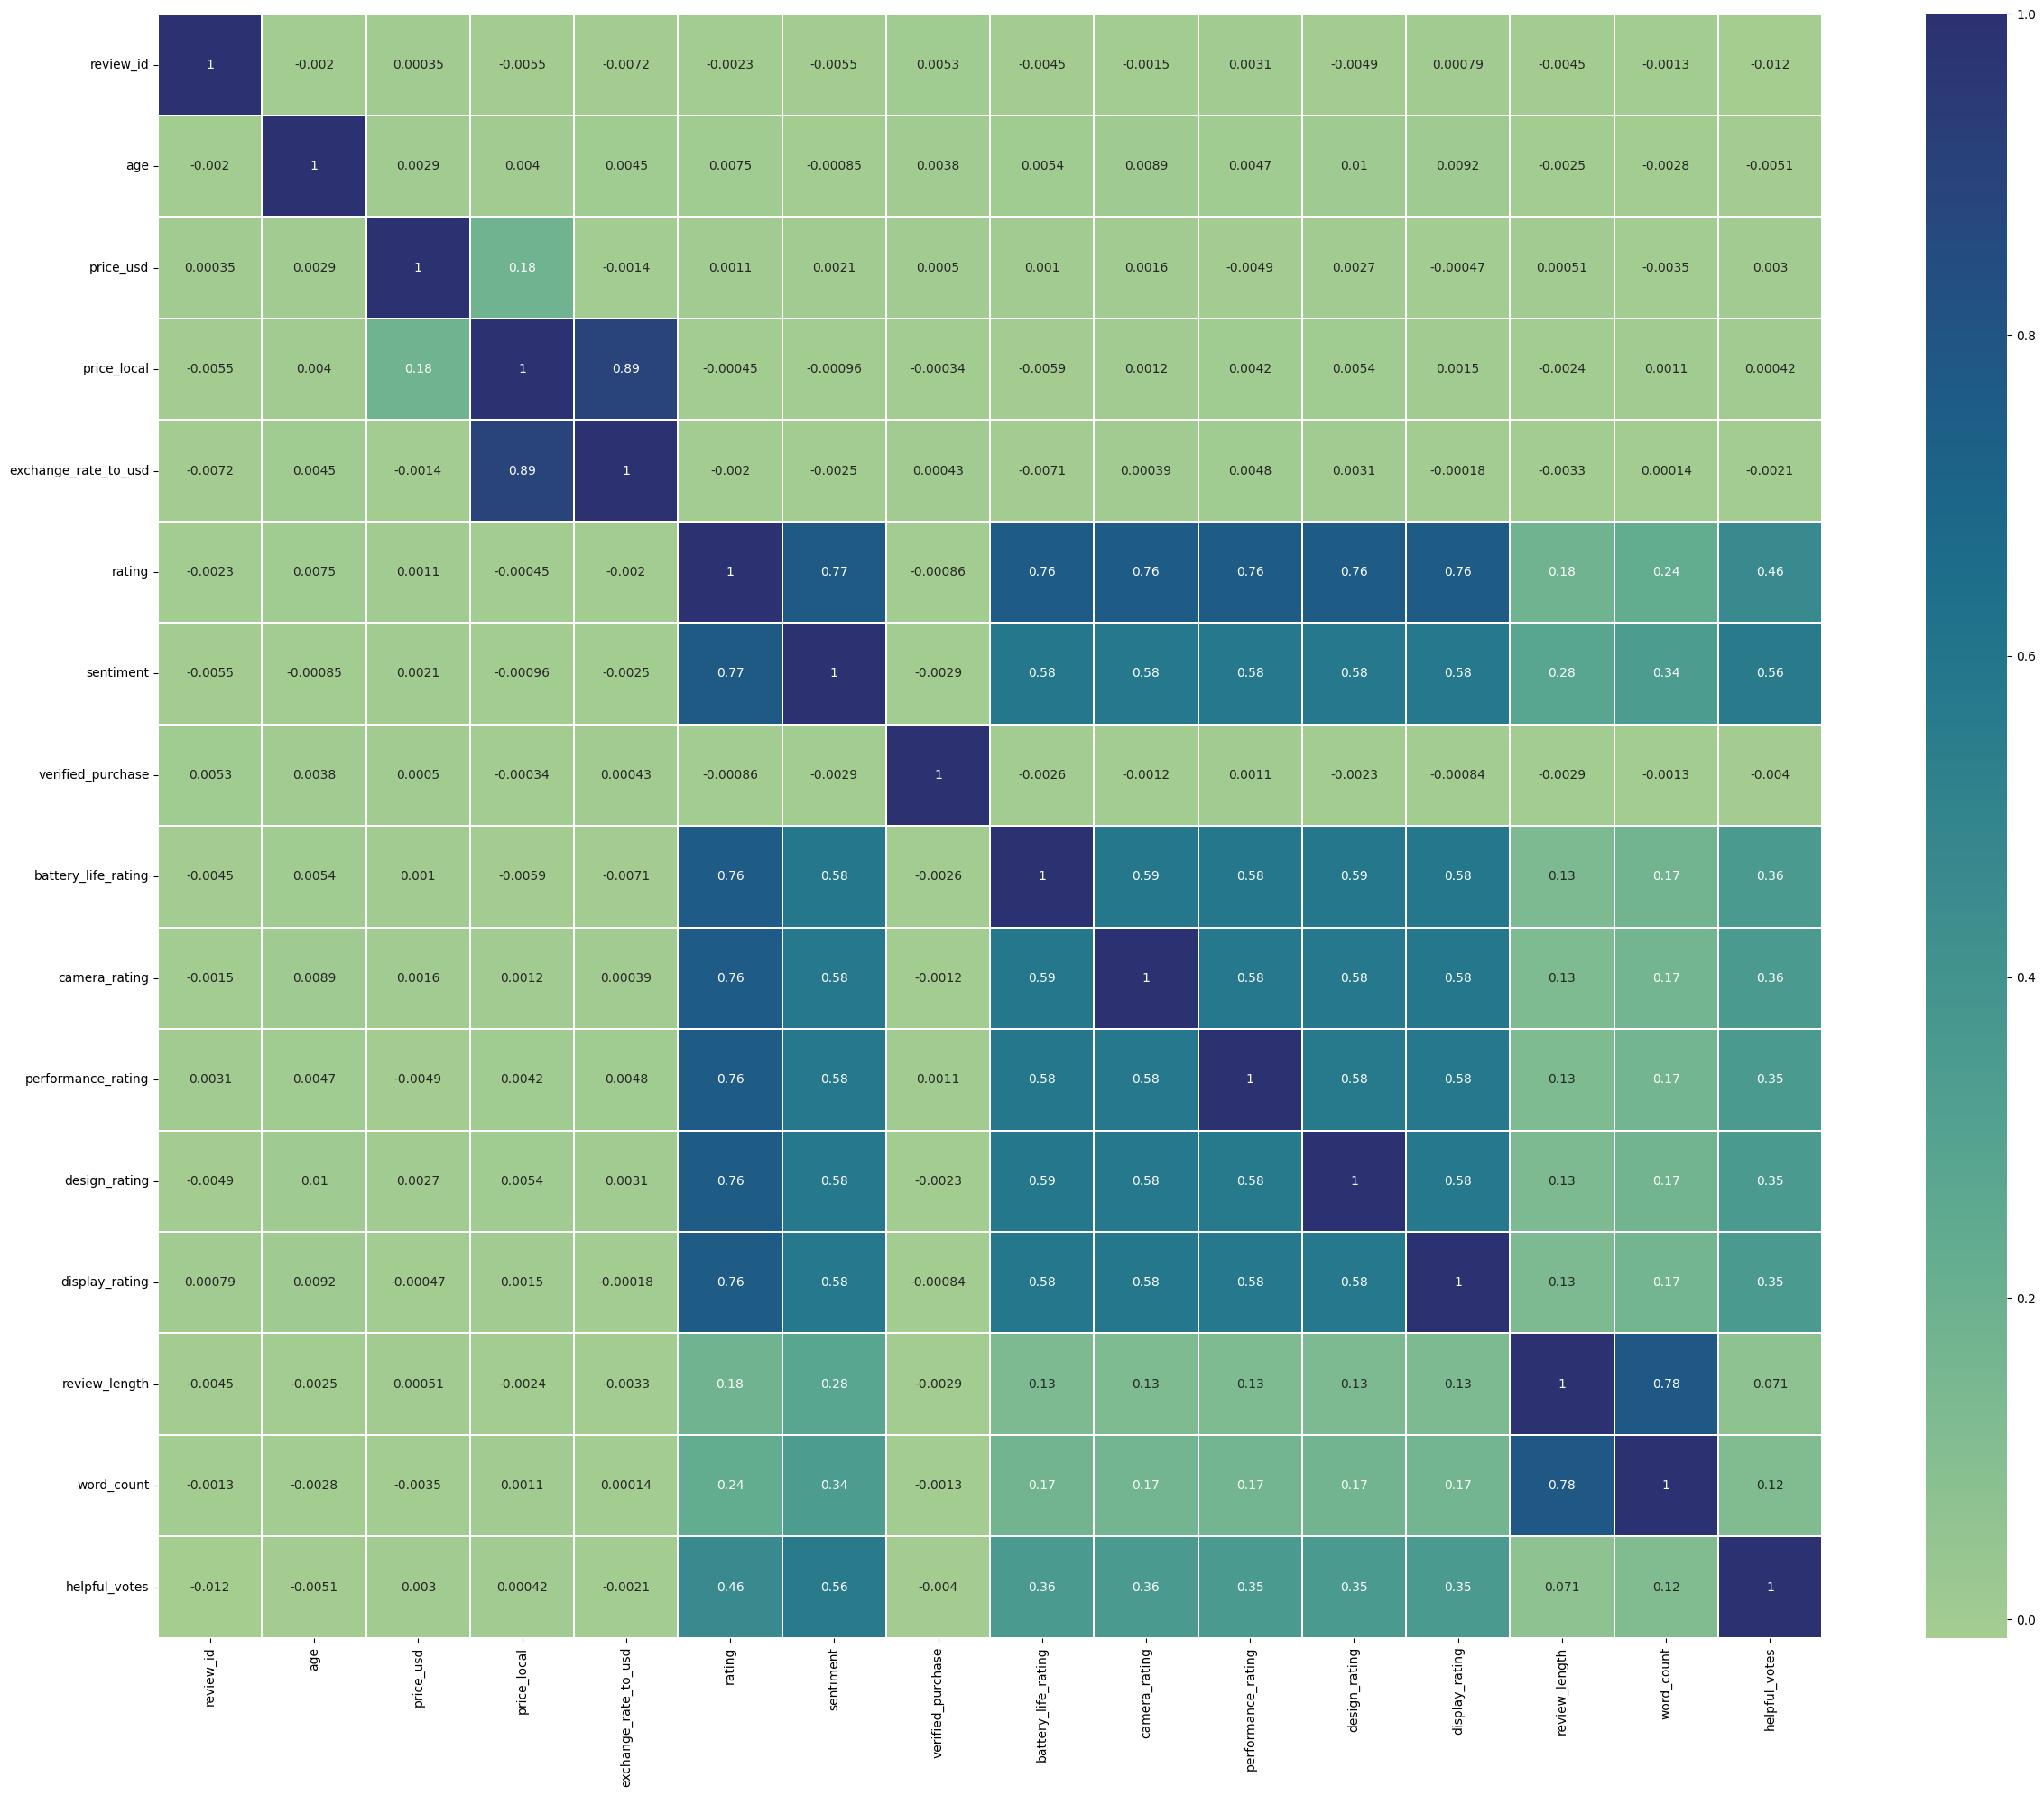

In [493]:
plt.figure(figsize=(25, 20))
sns.heatmap(data_corr[numeric_columns].corr(), annot=True, linewidths=0.01, cmap='crest');

plt.tight_layout()
plt.show()

In [495]:
X = data_corr[numeric_columns].drop(columns=['sentiment'])
vif_df = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif_df.sort_values('VIF', ascending=False))

                 feature         VIF
12         review_length  100.614228
13            word_count   78.393763
5                 rating   55.516396
7    battery_life_rating   12.095458
8          camera_rating   12.062939
11        display_rating   11.854316
10         design_rating   11.842974
9     performance_rating   11.814502
1                    age   10.803523
3            price_local    6.984556
4   exchange_rate_to_usd    6.965858
2              price_usd    6.718188
6      verified_purchase    4.810781
14         helpful_votes    4.107444
0              review_id    3.861552


**Высокие значения VIF:**

* `review_length`: Это очень высокое значение, что указывает на серьёзную мультиколлинеарность с другими признаками в данных. Этот столбец может быть сильно зависим от других числовых признаков, например, от `word_count`.

* `word_count`: Тоже очень высокое значение. Это логично, потому что `review_length` и `word_count` часто могут быть сильно коррелированы между собой, так как длина отзыва обычно соотносится с количеством слов.

* `rating`: Высокий VIF также. Рейтинг может быть связан с другими характеристиками устройства, такими как оценки батареи, камеры, производительности и т. д., что вызывает мультиколлинеарность.

**Значения VIF около 10:**

* `battery_life_rating`, `camera_rating`, `display_rating`, `design_rating`, `performance_rating`: Все эти признаки имеют значения VIF чуть выше 10. Это тоже указывает на наличие некоторой мультиколлинеарности, и их можно будет рассмотреть на дальнейших этапах анализа.

**Допустимые значения VIF:**

* `price_usd`, `price_local` и `age`: Эти признаки также показывают определённую зависимость друг от друга, особенно price_local и exchange_rate_to_usd, так как цена в локальной валюте зависит от курса обмена.

**Признаки с низким VIF:**

* `verified_purchase` и `helpful_votes`: Имеют относительно низкие значения VIF, что означает, что они не имеют значимой мультиколлинеарности с другими признаками, и их стоит оставить в модели.

* `review_id`: Имеет низкий VIF, но он, скорее всего, является просто уникальным идентификатором и не имеет смысла в модели (он не несёт информативной ценности). Этот признак можно удалить.

**Обоснование удаления фичей:**

* `review_id`: Это уникальный идентификатор для каждого отзыва. Он не содержит никакой информации о признаках, влияющих на оценку, и не должен участвовать в моделировании.
  
* `customer_name`: Это чисто идентификационный признак, который не несёт информации о содержимом отзыва или о характеристиках продукта. Использование этого признака может привести к переобучению модели, так как она будет запоминать уникальные идентификаторы пользователей, что не имеет отношения к анализу данных.
  
* `price_local` и `exchange_rate_to_usd`: Эти колонки коррелируют с `price_usd`, т.к. они являются линейной комбинацией. price_local * exchange_rate_to_usd = price_usd.

* `currency`: Эта фича коррелирована с переменной `country`, так как она ее дублирует данные. 
  
* `language`: Не влияет на контекст задачи, т.к. все отзывы написаны на английском.

In [496]:
data = data.drop(columns=['review_id', 'customer_name', 'price_local', 'exchange_rate_to_usd', 'currency', 'language', 'review_length'])

In [502]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   age                  50000 non-null  int64         
 1   brand                50000 non-null  object        
 2   model                50000 non-null  object        
 3   price_usd            50000 non-null  float64       
 4   rating               50000 non-null  int64         
 5   review_text          50000 non-null  object        
 6   sentiment            50000 non-null  int64         
 7   country              50000 non-null  object        
 8   review_date          50000 non-null  datetime64[ns]
 9   verified_purchase    50000 non-null  int64         
 10  battery_life_rating  50000 non-null  int64         
 11  camera_rating        50000 non-null  int64         
 12  performance_rating   50000 non-null  int64         
 13  design_rating        50000 non-

#### 2.6. Сохранение данных

In [504]:
data.to_csv('./data/Mobile Reviews Sentiment Pred.csv')

**Предварительная обработка данных:**

* Проведена очистка данных, удалены признаки, которые либо не несут полезной информации, либо могут привести к мультиколлинеарности. 

* Для некоторых колонок, таких как verified_purchase, выполнено преобразование булевых значений в числовые, что улучшает обработку данных и совместимость с алгоритмами машинного обучения.

**Анализ мультиколлинеарности:**

  * Использован VIF (Variance Inflation Factor) для оценки степени мультиколлинеарности между признаками. Результаты показали, что несколько признаков, таких как review_length и word_count, имеют очень высокие значения VIF (более 100), что указывает на сильную корреляцию между ними. Это может негативно повлиять на обучение модели, так как модель будет склонна "запоминать" избыточную информацию.

  * Ряд других признаков с высокими значениями VIF (например, rating, battery_life_rating, camera_rating) также подверглись анализу на наличие избыточности. Поэтому они объединены в один агрегированный показатель, чтобы уменьшить их влияние на модель.

  * Признаки price_local, exchange_rate_to_usd, и price_usd также показали значительную зависимость друг от друга, что подтверждает необходимость оставить только price_usd для устранения избыточности.

  * Признаки с низким VIF (например, verified_purchase и helpful_votes) не создают проблемы мультиколлинеарности и могут быть оставлены без изменений.


**Итог:**

Применённый анализ позволил значительно улучшить качество данных для дальнейшего анализа и моделирования. В данных: устранена мультиколлинеарность; уменьшена размерность данных и оптимизировали их для обучения моделей. Следующим шагом будет использование очищенных данных для построения и оценки различных моделей, что поможет получить более точные и стабильные предсказания.